# 1. NSL-KDD Data Loading

## 1.1 NSL-KDD Feature Schema

In [1]:
import pandas as pd

COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'label','difficulty'
]

## 1.2 Load Full Training & Test Sets

In [2]:
TRAIN_PATH = "/kaggle/input/nslkdd/KDDTrain+.txt"
TEST_PATH  = "/kaggle/input/nslkdd/KDDTest+.txt"

In [3]:
train_df = pd.read_csv(TRAIN_PATH, names=COLUMNS)
test_df  = pd.read_csv(TEST_PATH, names=COLUMNS)

print(train_df.shape)
print(test_df.shape)

(125973, 43)
(22544, 43)


## 1.3 Binary & Multiclass Label Construction

### 1.3.1 Binary labels (Normal vs Attack)

In [4]:
train_df['binary_label'] = train_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

test_df['binary_label'] = test_df['label'].apply(
    lambda x: 0 if x == 'normal' else 1
)

### 1.3.2 Multiclass Attack Mapping 

In [5]:
ATTACK_MAP = {
    'normal': 'Normal',

    # DoS
    'back': 'DoS','land': 'DoS','neptune': 'DoS','pod': 'DoS',
    'smurf': 'DoS','teardrop': 'DoS','mailbomb': 'DoS',
    'apache2': 'DoS','processtable': 'DoS','udpstorm': 'DoS',

    # Probe
    'ipsweep': 'Probe','nmap': 'Probe','portsweep': 'Probe','satan': 'Probe',
    'mscan': 'Probe','saint': 'Probe',

    # R2L
    'ftp_write': 'R2L','guess_passwd': 'R2L','imap': 'R2L',
    'multihop': 'R2L','phf': 'R2L','spy': 'R2L',
    'warezclient': 'R2L','warezmaster': 'R2L',
    'sendmail': 'R2L','named': 'R2L','snmpgetattack': 'R2L',
    'snmpguess': 'R2L','xlock': 'R2L','xsnoop': 'R2L','worm': 'R2L',

    # U2R
    'buffer_overflow': 'U2R','loadmodule': 'U2R',
    'perl': 'U2R','rootkit': 'U2R','httptunnel': 'U2R',
    'ps': 'U2R','sqlattack': 'U2R','xterm': 'U2R'
}

train_df['attack_class'] = train_df['label'].map(ATTACK_MAP)
test_df['attack_class']  = test_df['label'].map(ATTACK_MAP)

## 1.4 Drop Difficulty Column

## 1.4 Drop Difficulty Column

In [6]:
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'], inplace=True)

## 1.5 Quick Sanity Checks

In [7]:
print("Binary label distribution (train):")
print(train_df['binary_label'].value_counts())

print("\nAttack class distribution (train):")
print(train_df['attack_class'].value_counts())

Binary label distribution (train):
binary_label
0    67343
1    58630
Name: count, dtype: int64

Attack class distribution (train):
attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


# 2. NSL-KDD Data Preprocessing

## 2.1 Separate Features and Labels

In [8]:
from sklearn.model_selection import train_test_split

TARGET_BINARY = 'binary_label'
TARGET_MULTI  = 'attack_class'

X_train = train_df.drop(columns=['label', TARGET_BINARY, TARGET_MULTI])
y_train_bin = train_df[TARGET_BINARY]
y_train_multi = train_df[TARGET_MULTI]

X_test = test_df.drop(columns=['label', TARGET_BINARY, TARGET_MULTI])
y_test_bin = test_df[TARGET_BINARY]
y_test_multi = test_df[TARGET_MULTI]

## 2.2 Identify Feature Types

In [9]:
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

## 2.3 One-Hot Encode Categorical Features (Train–Test Safe)

In [10]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat  = ohe.transform(X_test[categorical_cols])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 2.4 Standardize Numerical Features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])

## 2.5 Concatenate Final Feature Matrices

In [12]:
import numpy as np

X_train_full = np.hstack([X_train_num, X_train_cat])
X_test_full  = np.hstack([X_test_num, X_test_cat])

print(X_train_full.shape, X_test_full.shape)

(125973, 122) (22544, 122)


## 2.6 Variance Threshold Prefilter

In [13]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.0)

X_train_var = var_filter.fit_transform(X_train_full)
X_test_var  = var_filter.transform(X_test_full)

print(X_train_var.shape)

(125973, 121)


## 2.7 Mutual Information Top-K Prefilter

In [14]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_var, 
    y_train_bin, 
    discrete_features=False,
    random_state=42
)

K = min(100, X_train_var.shape[1])

top_k_idx = np.argsort(mi_scores)[-K:]

X_train_prefiltered = X_train_var[:, top_k_idx]
X_test_prefiltered  = X_test_var[:, top_k_idx]

print(X_train_prefiltered.shape)

(125973, 100)


## 2.8 Saving Data

In [15]:
import os

SAVE_DIR = "/kaggle/working/NSL_KDD_Preprocessed"
os.makedirs(SAVE_DIR, exist_ok=True)

In [16]:
import numpy as np

np.save(f"{SAVE_DIR}/X_train.npy", X_train_prefiltered)
np.save(f"{SAVE_DIR}/X_test.npy", X_test_prefiltered)

In [17]:
np.save(f"{SAVE_DIR}/y_train_binary.npy", y_train_bin.values)
np.save(f"{SAVE_DIR}/y_test_binary.npy", y_test_bin.values)

In [18]:
np.save(f"{SAVE_DIR}/y_train_multi.npy", y_train_multi.values)
np.save(f"{SAVE_DIR}/y_test_multi.npy", y_test_multi.values)

In [22]:
np.save(f"{SAVE_DIR}/selected_feature_indices.npy", top_k_idx)

In [23]:
import joblib

joblib.dump(ohe, f"{SAVE_DIR}/onehot_encoder.joblib")
joblib.dump(scaler, f"{SAVE_DIR}/scaler.joblib")
joblib.dump(var_filter, f"{SAVE_DIR}/variance_filter.joblib")

['/kaggle/working/NSL_KDD_Preprocessed/variance_filter.joblib']

# 3. UNSW_NB15 Data Loading

## 3.1 File Paths

In [2]:
TRAIN_PATH = "/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv"
TEST_PATH  = "/kaggle/input/unsw-nb15/UNSW_NB15_testing-set.csv"

## 3.2 Load Training and Test Sets

In [3]:
import pandas as pd

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

(82332, 45)
(175341, 45)


## 3.3 Inspect Columns

In [4]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


## 3.4 Drop ID Column

In [5]:
train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

## 3.5 Define Labels (Binary + Multiclass)

### 3.5.1 Binary Labels

In [7]:
train_df['binary_label'] = train_df['label']
test_df['binary_label']  = test_df['label']

### 3.5.2 Multiclass Labels

In [10]:
train_df['attack_class'] = train_df['attack_cat']
test_df['attack_class']  = test_df['attack_cat']

## 3.6 Drop Original Label Columns

In [11]:
train_df.drop(columns=['label', 'attack_cat'], inplace=True)
test_df.drop(columns=['label', 'attack_cat'], inplace=True)

## 3.7 Separate Features and Targets

In [14]:
TARGET_BINARY = 'binary_label'
TARGET_MULTI  = 'attack_class'

X_train = train_df.drop(columns=[TARGET_BINARY, TARGET_MULTI])
y_train_bin = train_df[TARGET_BINARY]
y_train_multi = train_df[TARGET_MULTI]

X_test = test_df.drop(columns=[TARGET_BINARY, TARGET_MULTI])
y_test_bin = test_df[TARGET_BINARY]
y_test_multi = test_df[TARGET_MULTI]

## 3.8 Quick Sanity Checks

In [15]:
print("Binary label distribution (train):")
print(y_train_bin.value_counts())

print("\nAttack class distribution (train):")
print(y_train_multi.value_counts())

Binary label distribution (train):
binary_label
1    45332
0    37000
Name: count, dtype: int64

Attack class distribution (train):
attack_class
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


# 4. UNSW_NB15 Preprocessing

## 4.1 Identify Feature Types

In [16]:
categorical_cols = ['proto', 'service', 'state']
numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

## 4.2 One-Hot Encode Categorical Features

In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat  = ohe.transform(X_test[categorical_cols])

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## 4.3 Standardize Numerical Features

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])

## 4.4 Concatenate Encoded Feature Matrix

In [19]:
import numpy as np

X_train_full = np.hstack([X_train_num, X_train_cat])
X_test_full  = np.hstack([X_test_num, X_test_cat])

print(X_train_full.shape, X_test_full.shape)

(82332, 190) (175341, 190)


## 4.5 Variance Threshold Prefilter

In [20]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.0)

X_train_var = var_filter.fit_transform(X_train_full)
X_test_var  = var_filter.transform(X_test_full)

print(X_train_var.shape)

(82332, 190)


## 4.6 Mutual Information Top-K Selection

In [21]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_var,
    y_train_bin,
    random_state=42
)

K = min(120, X_train_var.shape[1])

top_k_idx = np.argsort(mi_scores)[-K:]

X_train_prefiltered = X_train_var[:, top_k_idx]
X_test_prefiltered  = X_test_var[:, top_k_idx]

print(X_train_prefiltered.shape)

(82332, 120)


## 4.7 Save Data

In [22]:
import numpy as np

SAVE_DIR = "/kaggle/working/unsw_nb15_preprocessed/"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(SAVE_DIR + "X_train.npy", X_train_prefiltered)
np.save(SAVE_DIR + "X_test.npy", X_test_prefiltered)

np.save(SAVE_DIR + "y_train_bin.npy", y_train_bin.values)
np.save(SAVE_DIR + "y_test_bin.npy", y_test_bin.values)

np.save(SAVE_DIR + "y_train_multi.npy", y_train_multi.values)
np.save(SAVE_DIR + "y_test_multi.npy", y_test_multi.values)

In [23]:
import joblib

joblib.dump(ohe, SAVE_DIR + "onehot_encoder.pkl")
joblib.dump(scaler, SAVE_DIR + "scaler.pkl")
joblib.dump(var_filter, SAVE_DIR + "variance_filter.pkl")
joblib.dump(top_k_idx, SAVE_DIR + "mi_topk_idx.pkl")

['/kaggle/working/unsw_nb15_preprocessed/mi_topk_idx.pkl']

# 5. CIC-IDS- 2017 Data Loading

## 5.1 File Paths

In [8]:
DATA_DIR = "/kaggle/input/network-intrusion-dataset/"

FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

## 5.2 Load and Concatenate All Files

In [9]:
import pandas as pd

dfs = []

for f in FILES:
    df = pd.read_csv(DATA_DIR + f)
    dfs.append(df)

cic_df = pd.concat(dfs, ignore_index=True)

print(cic_df.shape)

(2830743, 79)


## 5.3 Clean Column Names

In [11]:
cic_df.columns = cic_df.columns.str.strip().str.replace(' ', '_')

## 5.4 Remove Invalid / Infinite Values

In [12]:
import numpy as np

cic_df.replace([np.inf, -np.inf], np.nan, inplace=True)
cic_df.dropna(inplace=True)

print(cic_df.shape)

(2827876, 79)


## 5.5 Define Labels (Binary + Multiclass)

### 5.5.1 Binary Label (Normal vs Attack)

In [14]:
cic_df['binary_label'] = cic_df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

### 5.5.2 Multiclass Label

In [17]:
cic_df['attack_class'] = cic_df['Label']

## 5.6 Drop Non-Feature Columns

In [18]:
DROP_COLS = [
    'Flow_ID', 'Source_IP', 'Source_Port',
    'Destination_IP', 'Destination_Port',
    'Timestamp', 'Label'
]

DROP_COLS = [c for c in DROP_COLS if c in cic_df.columns]

cic_df.drop(columns=DROP_COLS, inplace=True)

## 5.7 Train–Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = cic_df.drop(columns=['binary_label', 'attack_class'])
y_bin = cic_df['binary_label']
y_multi = cic_df['attack_class']

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

## 5.8 Sanity Checks

In [20]:
print("Binary distribution:")
print(y_train_bin.value_counts())

print("\nAttack classes:")
print(y_train_multi.value_counts().head())

Binary distribution:
binary_label
0    1817055
1     445245
Name: count, dtype: int64

Attack classes:
attack_class
BENIGN           1817055
DoS Hulk          183866
PortScan          127231
DDoS              102462
DoS GoldenEye       8195
Name: count, dtype: int64


# 6. CIC-IDS- 2017 Preprocessing

## 6.1 Identify Feature Types

In [21]:
categorical_cols = []
numerical_cols = X_train.columns.tolist()

## 6.2 Standardize Numerical Features

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])

## 6.3 Feature Matrix

In [23]:
import numpy as np

X_train_full = X_train_num
X_test_full  = X_test_num

print(X_train_full.shape, X_test_full.shape)

(2262300, 77) (565576, 77)


## 6.4 Variance Threshold Prefilter

In [24]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.0)

X_train_var = var_filter.fit_transform(X_train_full)
X_test_var  = var_filter.transform(X_test_full)

print(X_train_var.shape)

(2262300, 69)


## 6.5 Mutual Information Top-K Selection

In [26]:
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif
import numpy as np

SUBSAMPLE_SIZE = 200_000

X_mi, y_mi = resample(
    X_train_var,
    y_train_bin,
    n_samples=min(SUBSAMPLE_SIZE, X_train_var.shape[0]),
    stratify=y_train_bin,
    random_state=42
)

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

K = min(150, X_train_var.shape[1])
top_k_idx = np.argsort(mi_scores)[-K:]

X_train_prefiltered = X_train_var[:, top_k_idx]
X_test_prefiltered  = X_test_var[:, top_k_idx]


print(X_train_prefiltered.shape)

(2262300, 69)


## 6.6 Save Data

In [27]:
import os

SAVE_DIR = "/kaggle/working/cicids2017_preprocessed/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [28]:
import numpy as np

np.save(SAVE_DIR + "X_train.npy", X_train_prefiltered)
np.save(SAVE_DIR + "X_test.npy", X_test_prefiltered)

np.save(SAVE_DIR + "y_train_bin.npy", y_train_bin.values)
np.save(SAVE_DIR + "y_test_bin.npy", y_test_bin.values)

np.save(SAVE_DIR + "y_train_multi.npy", y_train_multi.values)
np.save(SAVE_DIR + "y_test_multi.npy", y_test_multi.values)

In [29]:
import joblib

joblib.dump(scaler, SAVE_DIR + "scaler.pkl")
joblib.dump(var_filter, SAVE_DIR + "variance_filter.pkl")
joblib.dump(top_k_idx, SAVE_DIR + "mi_topk_idx.pkl")

['/kaggle/working/cicids2017_preprocessed/mi_topk_idx.pkl']

In [30]:
!pip install boruta

# 7. Boruta

## 7.1 Boruta Function

In [2]:
import numpy as np
import os
import joblib

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

In [3]:
def run_boruta(DATA_DIR, SAVE_NAME):
    X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
    X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))
    y_train = np.load(os.path.join(DATA_DIR, "y_train_bin.npy"))

    rf = RandomForestClassifier(
        n_estimators=500,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=50,
        alpha=0.05,
        two_step=True,
        random_state=42,
        verbose=2
    )

    boruta.fit(X_train, y_train)

    selected_idx = boruta.support_

    X_train_b = X_train[:, selected_idx]
    X_test_b  = X_test[:, selected_idx]

    SAVE_DIR = "/kaggle/working"
    os.makedirs(SAVE_DIR, exist_ok=True)

    np.save(SAVE_DIR + "/X_train_boruta.npy", X_train_b)
    np.save(SAVE_DIR + "/X_test_boruta.npy", X_test_b)

    joblib.dump(selected_idx, SAVE_DIR + "/selected_feature_idx.pkl")
    joblib.dump(boruta, SAVE_DIR + "/boruta_model.pkl")

    print(f"{SAVE_NAME}")
    print("Original features:", X_train.shape[1])
    print("Selected features:", X_train_b.shape[1])
    print("-" * 50)

In [4]:
run_boruta(
    DATA_DIR="/kaggle/input/cicids-2017-preprocessed/cicids_2017_preprocessed",
    SAVE_NAME="CIC-IDS2017 Boruta Completed"
)

Iteration: 	1 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	2 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	3 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	4 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	5 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	6 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	7 / 25
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	8 / 25
Confirmed: 	63
Tentative: 	6
Rejected: 	0
Iteration: 	9 / 25
Confirmed: 	63
Tentative: 	2
Rejected: 	4
Iteration: 	10 / 25
Confirmed: 	63
Tentative: 	2
Rejected: 	4
Iteration: 	11 / 25
Confirmed: 	63
Tentative: 	2
Rejected: 	4
Iteration: 	12 / 25
Confirmed: 	64
Tentative: 	1
Rejected: 	4
Iteration: 	13 / 25
Confirmed: 	64
Tentative: 	1
Rejected: 	4
Iteration: 	14 / 25
Confirmed: 	64
Tentative: 	1
Rejected: 	4
Iteration: 	15 / 25
Confirmed: 	64
Tentative: 	1
Rejected: 	4
Iteration: 	16 / 25
Confirmed: 	64
Tentative: 	1
Rejected: 	4
Iteration: 	17 / 

In [7]:
run_boruta(
    DATA_DIR="/kaggle/input/nslkdd-preprocessed/nslkdd_preprocessed",
    SAVE_NAME="NSL-KDD Boruta Completed"
)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	100
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	9 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	10 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	11 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	12 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	13 / 50
Confirmed: 	42
Tentative: 	2
Rejected: 	56
Iteration: 	14 / 50
Confirmed: 	42
Tentative: 	1
Rejected: 	57
Iteration: 	15 / 50
Confirmed: 	42
Tentative: 	1
Rejected: 	57
Iteration: 	16 / 50
Confirmed: 	42
Tentative: 	1
Rejected: 	57
I

In [4]:
run_boruta(
    DATA_DIR="/kaggle/input/unsw-nb15-preprocessed/unsw_nb15_preprocessed",
    SAVE_NAME="UNSW-NB15 Boruta Completed"
)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	120
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	9 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	10 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	11 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	12 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	13 / 50
Confirmed: 	38
Tentative: 	4
Rejected: 	78
Iteration: 	14 / 50
Confirmed: 	38
Tentative: 	3
Rejected: 	79
Iteration: 	15 / 50
Confirmed: 	38
Tentative: 	3
Rejected: 	79
Iteration: 	16 / 50
Confirmed: 	38
Tentative: 	3
Rejected: 	79
I

# 8. Sliding Window Generation

## 8.1 SW Function

In [26]:
import numpy as np
import os

In [27]:
def create_sliding_windows(X, y, window_size, stride=1):
    X_seq, y_seq = [], []

    for i in range(0, len(X) - window_size + 1, stride):
        X_seq.append(X[i:i + window_size])
        y_seq.append(y[i + window_size - 1])
    return np.array(X_seq), np.array(y_seq)

In [28]:
def process_dataset(
    X_DIR,
    Y_DIR,
    SAVE_NAME,
    window_size=10,
    stride=1
):
    X_train = np.load(os.path.join(X_DIR, "X_train_boruta.npy"))
    X_test  = np.load(os.path.join(X_DIR, "X_test_boruta.npy"))

    y_train = np.load(os.path.join(Y_DIR, "y_train_bin.npy"))
    y_test  = np.load(os.path.join(Y_DIR, "y_test_bin.npy"))

    X_train_seq, y_train_seq = create_sliding_windows(
        X_train, y_train, window_size, stride
    )

    X_test_seq, y_test_seq = create_sliding_windows(
        X_test, y_test, window_size, stride
    )

    SAVE_DIR = "/kaggle/working/"
    os.makedirs(SAVE_DIR, exist_ok=True)

    np.save(SAVE_DIR + "/X_train_seq.npy", X_train_seq)
    np.save(SAVE_DIR + "/y_train_seq.npy", y_train_seq)
    np.save(SAVE_DIR + "/X_test_seq.npy", X_test_seq)
    np.save(SAVE_DIR + "/y_test_seq.npy", y_test_seq)

    print(SAVE_NAME)
    print("Train sequences:", X_train_seq.shape)
    print("Test sequences :", X_test_seq.shape)
    print("-" * 60)

In [29]:
process_dataset(
    X_DIR="/kaggle/input/cicids-final/cicids_final",
    Y_DIR="/kaggle/input/cicids-2017-preprocessed/cicids_2017_preprocessed",
    SAVE_NAME="CIC-IDS2017 Sliding Windows",
    window_size=10,
    stride=1
)

CIC-IDS2017 Sliding Windows
Train sequences: (2262291, 10, 64)
Test sequences : (565567, 10, 64)
------------------------------------------------------------


In [13]:
process_dataset(
    X_DIR="/kaggle/input/nslkdd-final/nslkdd_final",
    Y_DIR="/kaggle/input/nslkdd-preprocessed/nslkdd_preprocessed",
    SAVE_NAME="NSL-KDD Sliding Windows",
    window_size=10,
    stride=1
)

NSL-KDD Sliding Windows
Train sequences: (125964, 10, 42)
Test sequences : (22535, 10, 42)
------------------------------------------------------------


In [15]:
process_dataset(
    X_DIR="/kaggle/input/unsw-final/unsw_final",
    Y_DIR="/kaggle/input/unsw-nb15-preprocessed/unsw_nb15_preprocessed",
    SAVE_NAME="UNSW-NB15 Sliding Windows",
    window_size=10,
    stride=1
)

UNSW-NB15 Sliding Windows
Train sequences: (82323, 10, 38)
Test sequences : (175332, 10, 38)
------------------------------------------------------------


# 9. QR-SAE + Classifier

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

## 9.1 Dataset Loader (Sequence Data)

In [8]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 9.2 Quasi-Recurrent Block (QR-Style)

In [9]:
class QRBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()

        self.conv_z = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size//2)
        self.conv_f = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        x = x.transpose(1, 2)          # (B, F, T)
        z = torch.tanh(self.conv_z(x))
        f = torch.sigmoid(self.conv_f(x))
        h = f * z
        return h.transpose(1, 2)       # (B, T, H)

## 9.3 QR-SAE + Classifier Model

In [10]:
class QRSAEClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        bottleneck_dim,
        num_classes,
        kernel_size=3
    ):
        super().__init__()

        self.encoder = QRBlock(input_dim, hidden_dim, kernel_size)
        self.bottleneck = nn.Linear(hidden_dim, bottleneck_dim)

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(bottleneck_dim, bottleneck_dim // 2),
            nn.ReLU(),
            nn.Linear(bottleneck_dim // 2, num_classes)
        )

    def forward(self, x):
        h = self.encoder(x)
        h_last = h[:, -1, :]
        z = self.bottleneck(h_last)

        recon = self.decoder(z)
        logits = self.classifier(z)

        return recon, logits

## 9.4 Load Sequence Data (Dataset-Agnostic)

In [11]:
def load_sequences(DATA_DIR):
    X_train = np.load(os.path.join(DATA_DIR, "X_train_seq.npy"))
    y_train = np.load(os.path.join(DATA_DIR, "y_train_seq.npy"))

    X_test = np.load(os.path.join(DATA_DIR, "X_test_seq.npy"))
    y_test = np.load(os.path.join(DATA_DIR, "y_test_seq.npy"))

    return X_train, y_train, X_test, y_test

## 9.5 Training Loop (Reconstruction + Classification)

In [12]:
def train_model(
    model,
    train_loader,
    optimizer,
    device,
    alpha=0.5
):
    model.train()
    total_loss = 0

    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    scaler = GradScaler()

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        with autocast():
            recon, logits = model(X)
            loss_recon = mse(recon, X[:, -1, :])
            loss_cls = ce(logits, y)
            loss = alpha * loss_recon + (1 - alpha) * loss_cls

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(train_loader)

## 9.6 Evaluation

In [13]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            _, logits = model(X)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

## 9.7 Full Training Runner (One Dataset)

In [14]:
def run_experiment(
    DATA_DIR,
    num_classes,
    epochs=10,
    batch_size=256
):
    X_train, y_train, X_test, y_test = load_sequences(DATA_DIR)

    train_ds = SequenceDataset(X_train, y_train)
    test_ds  = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = QRSAEClassifier(
        input_dim=X_train.shape[2],
        hidden_dim=128,
        bottleneck_dim=64,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        loss = train_model(model, train_loader, optimizer, device)
        acc = evaluate(model, test_loader, device)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Acc: {acc:.4f}")

    return model

## 9.8 NSL-KDD

In [14]:
run_experiment(
    DATA_DIR="/kaggle/input/nsl-seq/nsl-seq",
    num_classes=2
)

/tmp/ipykernel_47/3099651046.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/3099651046.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/10 | Loss: 0.1238 | Acc: 0.7607
Epoch 2/10 | Loss: 0.0533 | Acc: 0.7654
Epoch 3/10 | Loss: 0.0437 | Acc: 0.7738
Epoch 4/10 | Loss: 0.0351 | Acc: 0.7769
Epoch 5/10 | Loss: 0.0314 | Acc: 0.7849
Epoch 6/10 | Loss: 0.0293 | Acc: 0.7713
Epoch 7/10 | Loss: 0.0286 | Acc: 0.7846
Epoch 8/10 | Loss: 0.0239 | Acc: 0.7771
Epoch 9/10 | Loss: 0.0228 | Acc: 0.7748
Epoch 10/10 | Loss: 0.0250 | Acc: 0.7767


QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(42, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_f): Conv1d(42, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (bottleneck): Linear(in_features=128, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=42, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

## 9.9 UNSW-NB15

In [15]:
run_experiment(
    DATA_DIR="/kaggle/input/unsw-seq/unsw-seq",
    num_classes=2
)

/tmp/ipykernel_47/3099651046.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/3099651046.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/10 | Loss: 0.2517 | Acc: 0.9129
Epoch 2/10 | Loss: 0.0956 | Acc: 0.9129
Epoch 3/10 | Loss: 0.0735 | Acc: 0.8991
Epoch 4/10 | Loss: 0.0616 | Acc: 0.8940
Epoch 5/10 | Loss: 0.0574 | Acc: 0.9032
Epoch 6/10 | Loss: 0.0501 | Acc: 0.9053
Epoch 7/10 | Loss: 0.0496 | Acc: 0.9101
Epoch 8/10 | Loss: 0.0452 | Acc: 0.9151
Epoch 9/10 | Loss: 0.0422 | Acc: 0.8974
Epoch 10/10 | Loss: 0.0421 | Acc: 0.9157


QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(38, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_f): Conv1d(38, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (bottleneck): Linear(in_features=128, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=38, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

## 9.10 CIC-IDS2017

In [15]:
run_experiment(
    DATA_DIR="/kaggle/working/",
    num_classes=2
)

/tmp/ipykernel_47/3099651046.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/3099651046.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/10 | Loss: 0.1379 | Acc: 0.9690
Epoch 2/10 | Loss: 0.1052 | Acc: 0.9711
Epoch 3/10 | Loss: 0.1018 | Acc: 0.9695
Epoch 4/10 | Loss: 0.0985 | Acc: 0.9725
Epoch 5/10 | Loss: 0.0854 | Acc: 0.9722
Epoch 6/10 | Loss: 0.0871 | Acc: 0.9724
Epoch 7/10 | Loss: 0.0849 | Acc: 0.9746
Epoch 8/10 | Loss: 0.0765 | Acc: 0.9745
Epoch 9/10 | Loss: 0.0730 | Acc: 0.9751
Epoch 10/10 | Loss: 0.0794 | Acc: 0.9782


QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_f): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (bottleneck): Linear(in_features=128, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

# 10. Optuna

In [1]:
!pip install optuna

In [2]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

## 10.1 Load Sequence Data

In [6]:
def load_sequences(DATA_DIR):
    X_train = np.load(DATA_DIR + "/X_train_seq.npy")
    y_train = np.load(DATA_DIR + "/y_train_seq.npy")
    X_test = np.load(DATA_DIR + "/X_test_seq.npy")
    y_test = np.load(DATA_DIR + "/y_test_seq.npy")

    return X_train, y_train, X_test, y_test

## 10.2 Objective Function

In [8]:
def objective(trial, DATA_DIR, num_classes):

    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    bottleneck_dim = trial.suggest_categorical("bottleneck_dim", [32, 64, 128])
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5])
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    alpha = trial.suggest_float("alpha", 0.3, 0.7)

    X_train, y_train, X_test, y_test = load_sequences(DATA_DIR)

    train_ds = SequenceDataset(X_train, y_train)
    test_ds  = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=256)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = QRSAEClassifier(
        input_dim=X_train.shape[2],
        hidden_dim=hidden_dim,
        bottleneck_dim=bottleneck_dim,
        num_classes=num_classes,
        kernel_size=kernel_size
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    mse = nn.MSELoss()
    ce = nn.CrossEntropyLoss()

    model.train()
    for _ in range(5):
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            recon, logits = model(X)
            loss = alpha * mse(recon, X[:, -1, :]) + (1 - alpha) * ce(logits, y)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            _, logits = model(X)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

In [12]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
class QRBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.conv_z = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size//2)
        self.conv_f = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        x = x.transpose(1, 2)
        z = torch.tanh(self.conv_z(x))
        f = torch.sigmoid(self.conv_f(x))
        h = f * z
        return h.transpose(1, 2)

In [14]:
class QRSAEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, bottleneck_dim, num_classes, kernel_size):
        super().__init__()

        self.encoder = QRBlock(input_dim, hidden_dim, kernel_size)
        self.bottleneck = nn.Linear(hidden_dim, bottleneck_dim)

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(bottleneck_dim, bottleneck_dim // 2),
            nn.ReLU(),
            nn.Linear(bottleneck_dim // 2, num_classes)
        )

    def forward(self, x):
        h = self.encoder(x)
        h_last = h[:, -1, :]
        z = self.bottleneck(h_last)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return recon, logits

## 10.3 NSL-KDD

In [15]:
study_nsl = optuna.create_study(direction="maximize")
study_nsl.optimize(
    lambda trial: objective(
        trial,
        DATA_DIR="/kaggle/input/nsl-seq/nsl-seq",
        num_classes=2
    ),
    n_trials=20
)

print(study_nsl.best_params)

[I 2025-12-25 06:25:32,007] A new study created in memory with name: no-name-c132b73a-e788-402b-8139-0c4acc38b93f
/tmp/ipykernel_47/1692091859.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
[I 2025-12-25 06:25:47,852] Trial 0 finished with value: 0.7734191258043044 and parameters: {'hidden_dim': 256, 'bottleneck_dim': 64, 'kernel_size': 5, 'lr': 0.0012915784647594747, 'alpha': 0.48119819385420437}. Best is trial 0 with value: 0.7734191258043044.
/tmp/ipykernel_47/1692091859.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
[I 2025-12-25 06:25:59,618] Trial 1 finished w

{'hidden_dim': 256, 'bottleneck_dim': 128, 'kernel_size': 3, 'lr': 0.008945664207935407, 'alpha': 0.3748953626518686}


## 10.4 UNSW-NB15

In [16]:
study_unsw = optuna.create_study(direction="maximize")
study_unsw.optimize(
    lambda trial: objective(
        trial,
        DATA_DIR="/kaggle/input/unsw-seq/unsw-seq",
        num_classes=2
    ),
    n_trials=20
)

print(study_unsw.best_params)

[I 2025-12-25 06:33:36,895] A new study created in memory with name: no-name-64845e38-9437-44ee-ab16-b71afed900bc
/tmp/ipykernel_47/1692091859.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
[I 2025-12-25 06:33:49,400] Trial 0 finished with value: 0.9295507950630804 and parameters: {'hidden_dim': 64, 'bottleneck_dim': 32, 'kernel_size': 5, 'lr': 0.00020634564566023947, 'alpha': 0.5536245575460608}. Best is trial 0 with value: 0.9295507950630804.
[I 2025-12-25 06:33:59,117] Trial 1 finished with value: 0.9264367029407068 and parameters: {'hidden_dim': 256, 'bottleneck_dim': 64, 'kernel_size': 5, 'lr': 0.0006377466808555571, 'alpha': 0.5448179425773086}. Best is trial 0 with value: 0.9295507950630804.
[I 2025-12-25 06:34:08,821] Trial 2 finished with value: 0.9235792667624849 an

{'hidden_dim': 128, 'bottleneck_dim': 128, 'kernel_size': 5, 'lr': 0.0007146905174872819, 'alpha': 0.48708553074044264}


## 10.5 CIC-IDS2017

In [21]:
study_cic = optuna.create_study(direction="maximize")
study_cic.optimize(
    lambda trial: objective(
        trial,
        DATA_DIR="/kaggle/working",
        num_classes=2
    ),
    n_trials=20
)

print(study_cic.best_params)

[I 2025-12-25 06:38:36,235] A new study created in memory with name: no-name-0c0920cf-daba-45a9-b6bb-1a24bbb8f5d4
/tmp/ipykernel_47/1692091859.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
[I 2025-12-25 06:43:15,854] Trial 0 finished with value: 0.9673920154464458 and parameters: {'hidden_dim': 256, 'bottleneck_dim': 64, 'kernel_size': 5, 'lr': 0.0038782949944473114, 'alpha': 0.638908759402214}. Best is trial 0 with value: 0.9673920154464458.
[I 2025-12-25 06:47:54,241] Trial 1 finished with value: 0.970746171541126 and parameters: {'hidden_dim': 256, 'bottleneck_dim': 64, 'kernel_size': 3, 'lr': 0.004540257727466728, 'alpha': 0.35076000285771397}. Best is trial 1 with value: 0.970746171541126.
[I 2025-12-25 06:52:31,793] Trial 2 finished with value: 0.9686385521078846 and p

{'hidden_dim': 256, 'bottleneck_dim': 32, 'kernel_size': 5, 'lr': 0.0015750947951372904, 'alpha': 0.3857013570272726}


## 10.6 Save Best Hyperparameters

In [22]:
import json

with open("best_params_nsl.json", "w") as f:
    json.dump(study_nsl.best_params, f)

with open("best_params_unsw.json", "w") as f:
    json.dump(study_unsw.best_params, f)

with open("best_params_cic.json", "w") as f:
    json.dump(study_cic.best_params, f)

# 11. Final Models

In [17]:
import json
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

## 11.1 Dataset Loader

In [5]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 11.2 QR Block

In [6]:
class QRBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.conv_z = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size // 2)
        self.conv_f = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=kernel_size // 2)

    def forward(self, x):
        x = x.transpose(1, 2)
        z = torch.tanh(self.conv_z(x))
        f = torch.sigmoid(self.conv_f(x))
        h = f * z
        return h.transpose(1, 2)

## 11.3 QR-SAE + Classifier

In [7]:
class QRSAEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, bottleneck_dim, num_classes, kernel_size):
        super().__init__()

        self.encoder = QRBlock(input_dim, hidden_dim, kernel_size)
        self.bottleneck = nn.Linear(hidden_dim, bottleneck_dim)

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(bottleneck_dim, bottleneck_dim // 2),
            nn.ReLU(),
            nn.Linear(bottleneck_dim // 2, num_classes)
        )

    def forward(self, x):
        h = self.encoder(x)
        h_last = h[:, -1, :]
        z = self.bottleneck(h_last)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return recon, logits

## 11.4 Load Sequences

In [8]:
def load_sequences(DATA_DIR):
    X_train = np.load(DATA_DIR + "/X_train_seq.npy")
    y_train = np.load(DATA_DIR + "/y_train_seq.npy")
    X_test = np.load(DATA_DIR + "/X_test_seq.npy")
    y_test = np.load(DATA_DIR + "/y_test_seq.npy")
    return X_train, y_train, X_test, y_test

## 11.5 Final Training Function (BEST PARAMS)

In [20]:
def final_train(
    DATA_DIR,
    PARAM_PATH,
    SAVE_NAME,
    num_classes,
    epochs=30,
    batch_size=256
):
    with open(PARAM_PATH, "r") as f:
        params = json.load(f)

    X_train, y_train, X_test, y_test = load_sequences(DATA_DIR)

    train_ds = SequenceDataset(X_train, y_train)
    test_ds  = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = QRSAEClassifier(
        input_dim=X_train.shape[2],
        hidden_dim=params["hidden_dim"],
        bottleneck_dim=params["bottleneck_dim"],
        kernel_size=params["kernel_size"],
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"])
    mse = nn.MSELoss()
    ce  = nn.CrossEntropyLoss()
    scaler = GradScaler()

    best_test_acc = 0.0

    for epoch in range(epochs):
        # -------- TRAIN --------
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            with autocast():
                recon, logits = model(X)
                loss = (
                    params["alpha"] * mse(recon, X[:, -1, :]) +
                    (1 - params["alpha"]) * ce(logits, y)
                )

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total

        # -------- TEST --------
        model.eval()
        test_loss, test_correct, test_total = 0, 0, 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)

                recon, logits = model(X)
                loss = (
                    params["alpha"] * mse(recon, X[:, -1, :]) +
                    (1 - params["alpha"]) * ce(logits, y)
                )

                test_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                test_correct += (preds == y).sum().item()
                test_total += y.size(0)

        test_loss /= len(test_loader)
        test_acc = test_correct / test_total

        # -------- SAVE BEST MODEL --------
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), SAVE_NAME)
            saved = "✓ saved"
        else:
            saved = ""

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} {saved}"
        )

    print(f"\nBest Test Accuracy: {best_test_acc:.4f}")
    print("Best model saved to:", SAVE_NAME)

    return model

## 11.6 NSL-KDD

In [24]:
final_train(
    DATA_DIR="/kaggle/input/nsl-seq/nsl-seq",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_nsl.json",
    SAVE_NAME="final_model_nsl.pth",
    num_classes=2
)

/tmp/ipykernel_47/1854378187.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/1854378187.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Train Loss: 0.0750, Train Acc: 0.9816 | Test Loss: 0.8474, Test Acc: 0.7817 ✓ saved
Epoch 2/30 | Train Loss: 0.3450, Train Acc: 0.9892 | Test Loss: 0.6450, Test Acc: 0.7957 ✓ saved
Epoch 3/30 | Train Loss: 0.5477, Train Acc: 0.9898 | Test Loss: 1.1314, Test Acc: 0.7751 
Epoch 4/30 | Train Loss: 9.0907, Train Acc: 0.9885 | Test Loss: 0.6530, Test Acc: 0.7929 
Epoch 5/30 | Train Loss: 0.1278, Train Acc: 0.9919 | Test Loss: 1.0282, Test Acc: 0.7787 
Epoch 6/30 | Train Loss: 0.1253, Train Acc: 0.9924 | Test Loss: 1.0105, Test Acc: 0.7974 ✓ saved
Epoch 7/30 | Train Loss: 0.1236, Train Acc: 0.9928 | Test Loss: 0.8286, Test Acc: 0.7806 
Epoch 8/30 | Train Loss: 0.1227, Train Acc: 0.9932 | Test Loss: 0.8720, Test Acc: 0.7898 
Epoch 9/30 | Train Loss: 0.1219, Train Acc: 0.9931 | Test Loss: 1.0812, Test Acc: 0.7921 
Epoch 10/30 | Train Loss: 0.1212, Train Acc: 0.9937 | Test Loss: 0.7154, Test Acc: 0.7811 
Epoch 11/30 | Train Loss: 0.1208, Train Acc: 0.9938 | Test Loss: 0.9384, Test 

QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(42, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_f): Conv1d(42, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (bottleneck): Linear(in_features=256, out_features=128, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=42, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

## 11.7 UNSW-NB15

In [25]:
final_train(
    DATA_DIR="/kaggle/input/unsw-seq/unsw-seq",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_unsw.json",
    SAVE_NAME="final_model_unsw.pth",
    num_classes=2
)

/tmp/ipykernel_47/1854378187.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/1854378187.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Train Loss: 0.2389, Train Acc: 0.9312 | Test Loss: 0.1729, Test Acc: 0.9369 ✓ saved
Epoch 2/30 | Train Loss: 0.0839, Train Acc: 0.9719 | Test Loss: 0.1581, Test Acc: 0.9309 
Epoch 3/30 | Train Loss: 0.0614, Train Acc: 0.9759 | Test Loss: 0.1491, Test Acc: 0.9334 
Epoch 4/30 | Train Loss: 0.0496, Train Acc: 0.9780 | Test Loss: 0.1580, Test Acc: 0.9277 
Epoch 5/30 | Train Loss: 0.0431, Train Acc: 0.9800 | Test Loss: 0.1559, Test Acc: 0.9261 
Epoch 6/30 | Train Loss: 0.0409, Train Acc: 0.9815 | Test Loss: 0.1468, Test Acc: 0.9340 
Epoch 7/30 | Train Loss: 0.0366, Train Acc: 0.9824 | Test Loss: 0.1608, Test Acc: 0.9291 
Epoch 8/30 | Train Loss: 0.0346, Train Acc: 0.9840 | Test Loss: 0.1716, Test Acc: 0.9203 
Epoch 9/30 | Train Loss: 0.0322, Train Acc: 0.9845 | Test Loss: 0.1528, Test Acc: 0.9302 
Epoch 10/30 | Train Loss: 0.0291, Train Acc: 0.9852 | Test Loss: 0.1834, Test Acc: 0.9186 
Epoch 11/30 | Train Loss: 0.0292, Train Acc: 0.9857 | Test Loss: 0.2053, Test Acc: 0.9140 
E

QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(38, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (conv_f): Conv1d(38, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (bottleneck): Linear(in_features=128, out_features=128, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=38, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

## 11.8 CIC-IDS2017

In [30]:
final_train(
    DATA_DIR="/kaggle/working",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_cic.json",
    SAVE_NAME="final_model_cic.pth",
    num_classes=2
)

/tmp/ipykernel_47/1854378187.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/1854378187.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/30 | Train Loss: 0.1255, Train Acc: 0.9622 | Test Loss: 0.1900, Test Acc: 0.9681 ✓ saved
Epoch 2/30 | Train Loss: 0.1027, Train Acc: 0.9693 | Test Loss: 0.1409, Test Acc: 0.9683 ✓ saved
Epoch 3/30 | Train Loss: 0.0862, Train Acc: 0.9705 | Test Loss: 0.1811, Test Acc: 0.9710 ✓ saved
Epoch 4/30 | Train Loss: 0.0860, Train Acc: 0.9711 | Test Loss: 0.1698, Test Acc: 0.9709 
Epoch 5/30 | Train Loss: 0.0837, Train Acc: 0.9714 | Test Loss: 0.1637, Test Acc: 0.9716 ✓ saved
Epoch 6/30 | Train Loss: 0.0819, Train Acc: 0.9716 | Test Loss: 0.1499, Test Acc: 0.9712 
Epoch 7/30 | Train Loss: 0.0812, Train Acc: 0.9719 | Test Loss: 0.1733, Test Acc: 0.9713 
Epoch 8/30 | Train Loss: 0.0752, Train Acc: 0.9719 | Test Loss: 0.1396, Test Acc: 0.9721 ✓ saved
Epoch 9/30 | Train Loss: 0.0856, Train Acc: 0.9720 | Test Loss: 0.1271, Test Acc: 0.9712 
Epoch 10/30 | Train Loss: 0.0785, Train Acc: 0.9721 | Test Loss: 0.1465, Test Acc: 0.9721 ✓ saved
Epoch 11/30 | Train Loss: 0.0744, Train Acc: 0.9723 | Tes

QRSAEClassifier(
  (encoder): QRBlock(
    (conv_z): Conv1d(64, 256, kernel_size=(5,), stride=(1,), padding=(2,))
    (conv_f): Conv1d(64, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (bottleneck): Linear(in_features=256, out_features=32, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)

# 12. Evaluation

In [31]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

## 12.1 Load Trained Model

In [32]:
def load_trained_model(
    model,
    MODEL_PATH,
    device
):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    return model

## 12.2 Get Predictions & Probabilities

In [33]:
def get_predictions(model, loader, device):
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model(X)[1]
            probs = torch.softmax(logits, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())  # binary case

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

## 12.3 Evaluation Function

In [34]:
def evaluate_metrics(y_true, y_pred, y_prob):
    results = {}

    results["Accuracy"] = accuracy_score(y_true, y_pred)

    results["Precision_macro"] = precision_score(y_true, y_pred, average="macro")
    results["Precision_micro"] = precision_score(y_true, y_pred, average="micro")
    results["Precision_weighted"] = precision_score(y_true, y_pred, average="weighted")

    results["Recall_macro"] = recall_score(y_true, y_pred, average="macro")
    results["Recall_micro"] = recall_score(y_true, y_pred, average="micro")
    results["Recall_weighted"] = recall_score(y_true, y_pred, average="weighted")

    results["F1_macro"] = f1_score(y_true, y_pred, average="macro")
    results["F1_micro"] = f1_score(y_true, y_pred, average="micro")
    results["F1_weighted"] = f1_score(y_true, y_pred, average="weighted")

    results["ROC_AUC"] = roc_auc_score(y_true, y_prob)
    results["PR_AUC"] = average_precision_score(y_true, y_prob)

    results["MCC"] = matthews_corrcoef(y_true, y_pred)

    return results

## 12.4 Run Evaluation

In [38]:
def load_trained_model_from_params(
    DATA_DIR,
    MODEL_PATH,
    PARAM_PATH,
    num_classes
):
    with open(PARAM_PATH, "r") as f:
        params = json.load(f)

    X_test = np.load(DATA_DIR + "/X_test_seq.npy")
    input_dim = X_test.shape[2]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = QRSAEClassifier(
        input_dim=input_dim,
        hidden_dim=params["hidden_dim"],
        bottleneck_dim=params["bottleneck_dim"],
        kernel_size=params["kernel_size"],
        num_classes=num_classes
    ).to(device)

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    return model, device

def run_evaluation(
    DATA_DIR,
    MODEL_PATH,
    PARAM_PATH,
    num_classes
):
    X_test = np.load(DATA_DIR + "/X_test_seq.npy")
    y_test = np.load(DATA_DIR + "/y_test_seq.npy")

    test_ds = SequenceDataset(X_test, y_test)
    test_loader = DataLoader(test_ds, batch_size=512)

    model, device = load_trained_model_from_params(
        DATA_DIR,
        MODEL_PATH,
        PARAM_PATH,
        num_classes
    )

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            logits = model(X)[1]
            probs = torch.softmax(logits, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision (macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))
    print("MCC:", matthews_corrcoef(y_true, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))


## 12.5 NSL-KDD

In [40]:
run_evaluation(
    DATA_DIR="/kaggle/input/nsl-seq/nsl-seq",
    MODEL_PATH="final_model_nsl.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_nsl.json",
    num_classes=2
)

Accuracy: 0.8167739072553806
Precision (macro): 0.8341772133453424
Recall (macro): 0.8333484030326804
F1 (macro): 0.8167705820188469
ROC-AUC: 0.9176707190144253
PR-AUC: 0.9405565252409798
MCC: 0.6675251018458593

Confusion Matrix
[[9251  456]
 [3673 9155]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.95      0.82      9707
           1       0.95      0.71      0.82     12828

    accuracy                           0.82     22535
   macro avg       0.83      0.83      0.82     22535
weighted avg       0.85      0.82      0.82     22535



## 12.6 UNSW-NB15

In [41]:
run_evaluation(
    DATA_DIR="/kaggle/input/unsw-seq/unsw-seq",
    MODEL_PATH="final_model_unsw.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_unsw.json",
    num_classes=2
)

Accuracy: 0.9368968585312436
Precision (macro): 0.9258829631245955
Recall (macro): 0.9296925403940283
F1 (macro): 0.9277475561233841
ROC-AUC: 0.9805535551451636
PR-AUC: 0.9888841884979137
MCC: 0.8555670221216891

Confusion Matrix
[[ 50938   5053]
 [  6011 113330]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     55991
           1       0.96      0.95      0.95    119341

    accuracy                           0.94    175332
   macro avg       0.93      0.93      0.93    175332
weighted avg       0.94      0.94      0.94    175332



## 12.7 CIC-IDS2017

In [47]:
run_evaluation(
    DATA_DIR="/kaggle/working",
    MODEL_PATH="final_model_cic.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_cic.json",
    num_classes=2
)

Accuracy: 0.9777179361596415
Precision (macro): 0.9657826253038626
Recall (macro): 0.9635792342545852
F1 (macro): 0.9646760017616905
ROC-AUC: 0.9968966461213257
PR-AUC: 0.9882886522074089
MCC: 0.9293592475839577

Confusion Matrix
[[448309   5953]
 [  6649 104656]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    454262
           1       0.95      0.94      0.94    111305

    accuracy                           0.98    565567
   macro avg       0.97      0.96      0.96    565567
weighted avg       0.98      0.98      0.98    565567



# 13. Latency and FLOPs

In [50]:
!pip install thop

In [51]:
import time
import torch
import numpy as np
from thop import profile

## 13.1 Latency Measurement Code

In [52]:
def measure_latency(model, input_tensor, device, runs=200):
    model.eval()
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        for _ in range(10):
            _ = model(input_tensor)

    start = time.time()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(input_tensor)
    end = time.time()

    latency_ms = ((end - start) / runs) * 1000
    return latency_ms

## 13.2 FLOPs & Parameter Count

In [53]:
def measure_flops_params(model, input_tensor):
    flops, params = profile(
        model,
        inputs=(input_tensor,),
        verbose=False
    )
    return flops, params

## 13.3 Model Size (MB)

In [54]:
def get_model_size_mb(model):
    size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return size_bytes / (1024 ** 2)

## 13.4 Unified Benchmark Runner

In [57]:
def benchmark_model(
    DATA_DIR,
    MODEL_PATH,
    PARAM_PATH,
    num_classes,
    name="Dataset"
):
    # Load Optuna params
    with open(PARAM_PATH, "r") as f:
        params = json.load(f)

    X_test = np.load(DATA_DIR + "/X_test_seq.npy")
    sample = torch.tensor(X_test[:1], dtype=torch.float32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Rebuild model EXACTLY as trained
    model = QRSAEClassifier(
        input_dim=sample.shape[2],
        hidden_dim=params["hidden_dim"],
        bottleneck_dim=params["bottleneck_dim"],
        kernel_size=params["kernel_size"],
        num_classes=num_classes
    )

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample.to(device))

    # Latency
    runs = 200
    start = time.time()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(sample.to(device))
    latency_ms = ((time.time() - start) / runs) * 1000

    # FLOPs & Params
    flops, params_count = profile(
        model,
        inputs=(sample.to(device),),
        verbose=False
    )

    # Model size
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

    print(f"\n===== {name} Benchmark =====")
    print(f"Latency (ms/sample): {latency_ms:.4f}")
    print(f"FLOPs: {flops / 1e6:.2f} MFLOPs")
    print(f"Parameters: {params_count / 1e6:.2f} M")
    print(f"Model Size: {size_mb:.2f} MB")

## 13.5 NSL-KDD

In [58]:
benchmark_model(
    DATA_DIR="/kaggle/input/nsl-seq/nsl-seq",
    MODEL_PATH="final_model_nsl.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_nsl.json",
    num_classes=2,
    name="NSL-KDD"
)


===== NSL-KDD Benchmark =====
Latency (ms/sample): 0.5454
FLOPs: 0.73 MFLOPs
Parameters: 0.15 M
Model Size: 0.57 MB


## 13.6 UNSW-NB15

In [59]:
benchmark_model(
    DATA_DIR="/kaggle/input/unsw-seq/unsw-seq",
    MODEL_PATH="final_model_unsw.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_unsw.json",
    num_classes=2,
    name="UNSW-NB15"
)


===== UNSW-NB15 Benchmark =====
Latency (ms/sample): 0.5035
FLOPs: 0.53 MFLOPs
Parameters: 0.10 M
Model Size: 0.36 MB


## 13.7 CIC-IDS2017

In [60]:
benchmark_model(
    DATA_DIR="/kaggle/working",
    MODEL_PATH="final_model_cic.pth",
    PARAM_PATH="/kaggle/input/bin-param/bin_param/best_params_cic.json",
    num_classes=2,
    name="CIC-IDS2017"
)


===== CIC-IDS2017 Benchmark =====
Latency (ms/sample): 0.6485
FLOPs: 1.67 MFLOPs
Parameters: 0.20 M
Model Size: 0.76 MB


# 14. Visualizations

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

## 14.1 Confusion Matrix Plot

In [63]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

## 14.2 ROC Curve

In [64]:
def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 14.3 Precision–Recall Curve

In [65]:
def plot_pr_curve(y_true, y_prob, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 14.4 Latency Comparison Bar Chart

In [66]:
def plot_inter_dataset_latency(datasets, latencies):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.bar(datasets, latencies)
    plt.ylabel("Latency (ms/sample)")
    plt.title("Inter-Dataset Latency Comparison (QR-SAE)")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

## 14.5 Feature Count vs Performance Plot

In [67]:
def plot_inter_dataset_feature_performance(
    feature_counts,
    f1_scores,
    dataset_labels
):
    import matplotlib.pyplot as plt

    plt.figure()
    for feats, f1, label in zip(feature_counts, f1_scores, dataset_labels):
        plt.plot(feats, f1, marker="o", label=label)

    plt.xlabel("Number of Selected Features")
    plt.ylabel("F1-score")
    plt.title("Feature Count vs Performance (Inter-Dataset)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 14.6 Unified Visualization Runner

In [73]:
def unified_visualization_runner(
    dataset_configs,
    inter_latency_datasets,
    inter_latency_values,
    inter_feature_counts,
    inter_f1_scores
):
    import torch
    import numpy as np
    from torch.utils.data import DataLoader

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # -------- PER-DATASET VISUALS --------
    for cfg in dataset_configs:
        DATA_DIR = cfg["data_dir"]
        MODEL_PATH = cfg["model_path"]
        DATASET_NAME = cfg["name"]
        NUM_CLASSES = cfg["num_classes"]

        X_test = np.load(DATA_DIR + "/X_test_seq.npy")
        y_test = np.load(DATA_DIR + "/y_test_seq.npy")

        test_ds = SequenceDataset(X_test, y_test)
        test_loader = DataLoader(test_ds, batch_size=512)
        
        model = load_trained_model_with_params(
            DATA_DIR=DATA_DIR,
            MODEL_PATH=MODEL_PATH,
            PARAM_PATH=cfg["param_path"],
            input_dim=X_test.shape[2],
            num_classes=NUM_CLASSES,
            device=device
        )

        y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

        plot_confusion_matrix(
            y_true,
            y_pred,
            f"Confusion Matrix – {DATASET_NAME}"
        )

        plot_roc_curve(
            y_true,
            y_prob,
            f"ROC Curve – {DATASET_NAME}"
        )

        plot_pr_curve(
            y_true,
            y_prob,
            f"PR Curve – {DATASET_NAME}"
        )

    # -------- INTER-DATASET VISUALS (ONCE) --------
    plot_inter_dataset_latency(
        inter_latency_datasets,
        inter_latency_values
    )

    plot_inter_dataset_feature_performance(
        inter_feature_counts,
        inter_f1_scores,
        inter_latency_datasets
    )

In [74]:
dataset_configs = [
    {
        "name": "NSL-KDD",
        "data_dir": "/kaggle/input/nsl-seq/nsl-seq",
        "model_path": "final_model_nsl.pth",
        "param_path": "/kaggle/input/bin-param/bin_param/best_params_nsl.json",
        "num_classes": 2
    },
    {
        "name": "UNSW-NB15",
        "data_dir": "/kaggle/input/unsw-seq/unsw-seq",
        "model_path": "final_model_unsw.pth",
        "param_path": "/kaggle/input/bin-param/bin_param/best_params_unsw.json",
        "num_classes": 2
    },
    {
        "name": "CIC-IDS2017",
        "data_dir": "/kaggle/working",
        "model_path": "final_model_cic.pth",
        "param_path": "/kaggle/input/bin-param/bin_param/best_params_cic.json",
        "num_classes": 2
    }
]


inter_latency_datasets = ["NSL-KDD", "UNSW-NB15", "CIC-IDS2017"]
inter_latency_values = [0.54, 0.50, 0.64]

inter_feature_counts = [
    [48],      # NSL-KDD
    [32],     # UNSW-NB15
    [64]      # CIC-IDS2017
]

inter_f1_scores = [
    [0.81],
    [0.92],
    [0.96]
]

In [75]:
import json

def load_trained_model_with_params(
    DATA_DIR,
    MODEL_PATH,
    PARAM_PATH,
    input_dim,
    num_classes,
    device
):
    with open(PARAM_PATH, "r") as f:
        params = json.load(f)

    model = QRSAEClassifier(
        input_dim=input_dim,
        hidden_dim=params["hidden_dim"],
        bottleneck_dim=params["bottleneck_dim"],
        kernel_size=params["kernel_size"],
        num_classes=num_classes
    )

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    return model

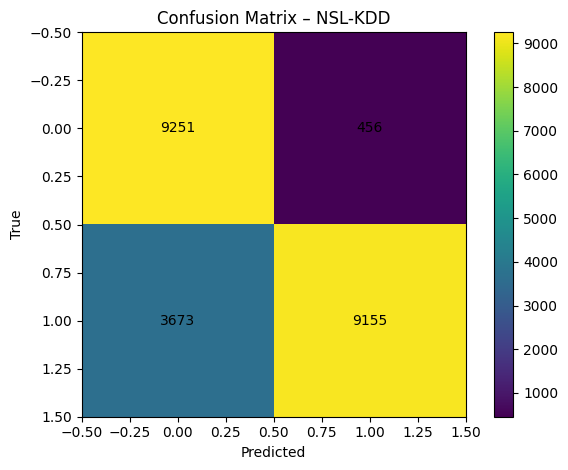

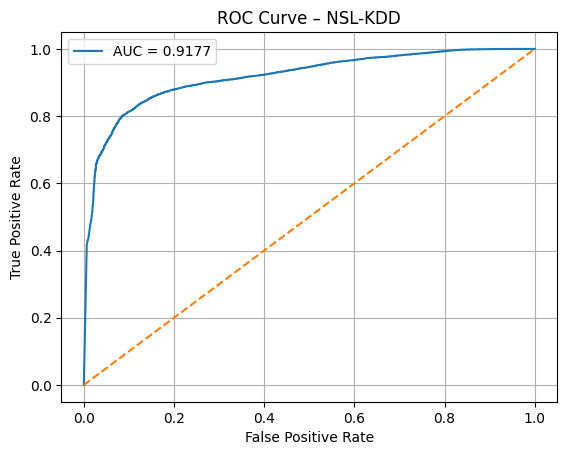

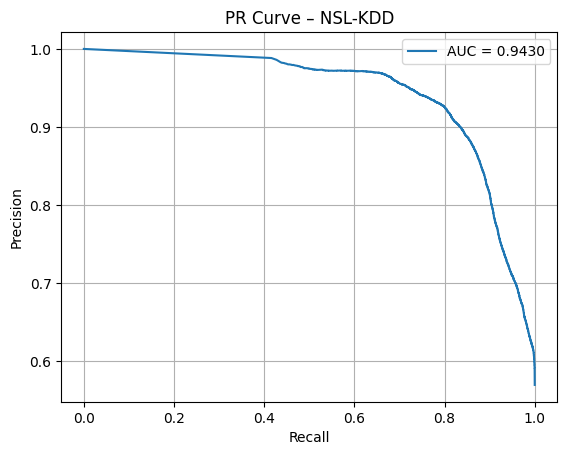

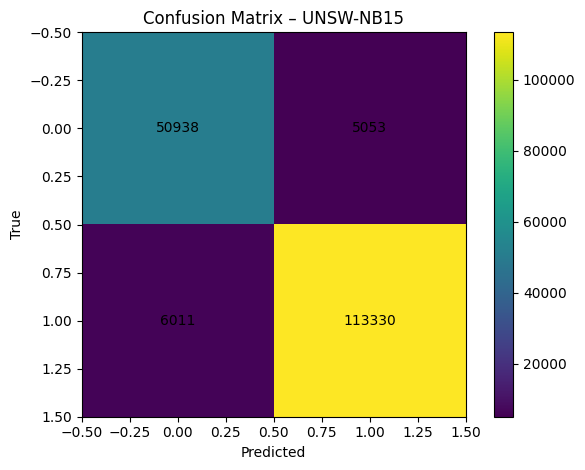

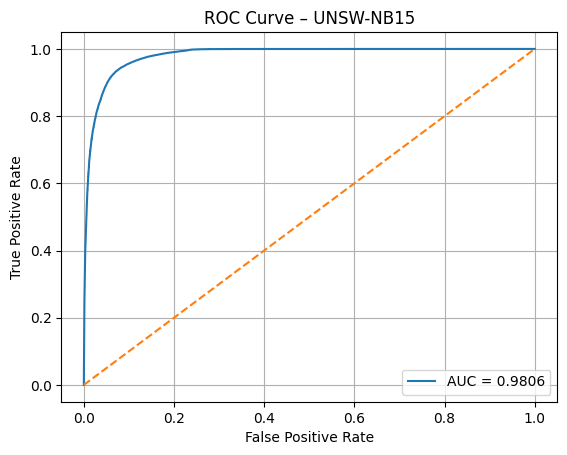

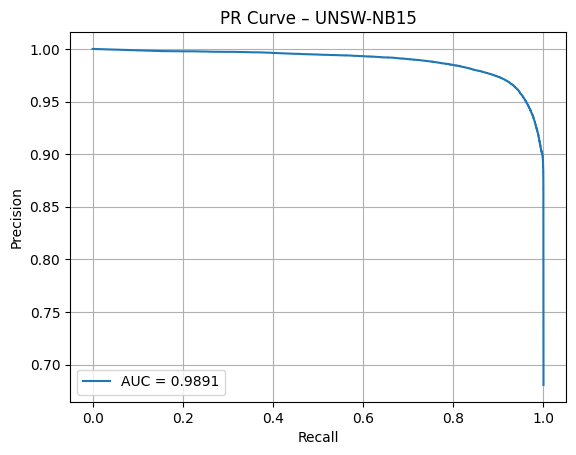

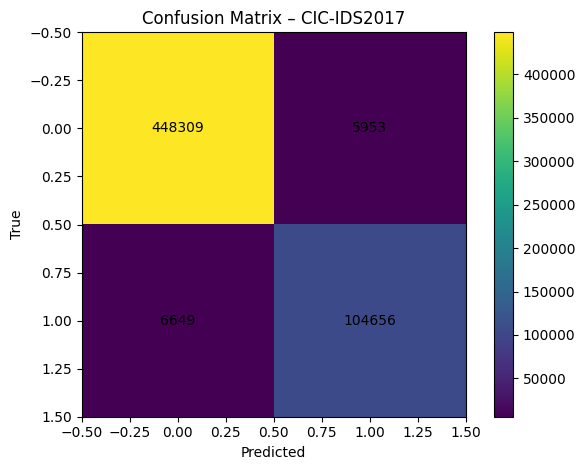

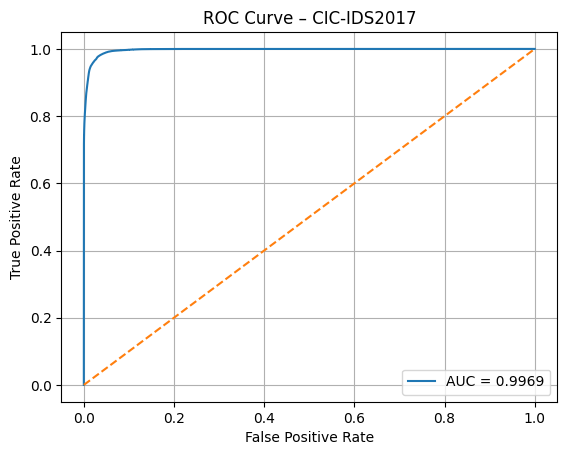

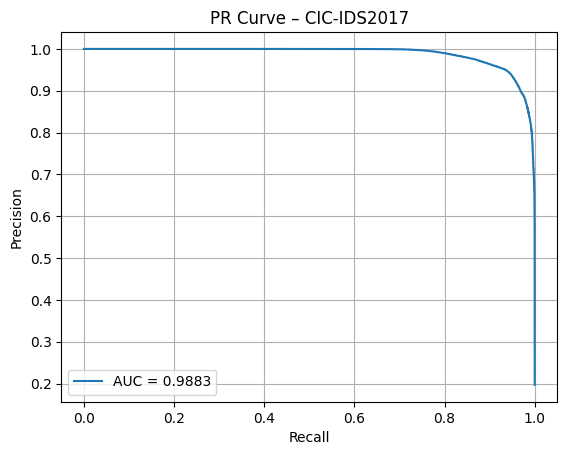

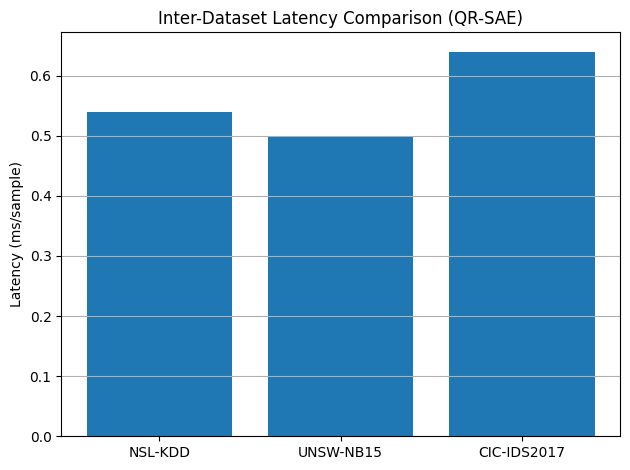

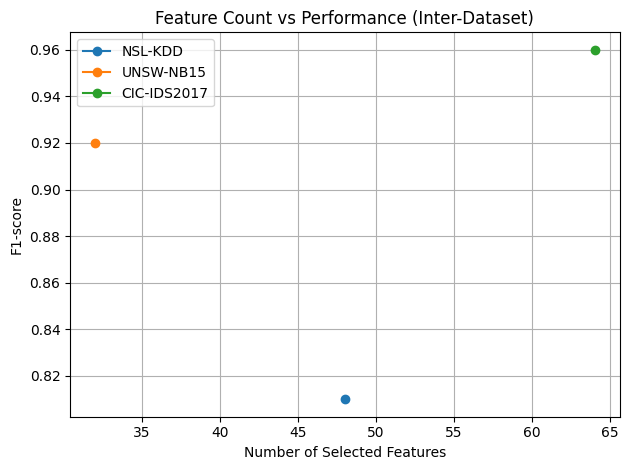

In [76]:
unified_visualization_runner(
    dataset_configs,
    inter_latency_datasets,
    inter_latency_values,
    inter_feature_counts,
    inter_f1_scores
)